In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [3]:
df=pd.read_csv("Groceries_dataset.csv")
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [6]:
pip install tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/332.0 MB 1.4 MB/s eta 0:04:02
   ---------------------------------------- 1.0/332.0 MB 1.3 MB/s eta 0:04:17
   ---------------------------------------- 1.3/332.0 MB 1.4 MB/s eta 0:04:00
   ---------------------------------------- 1.6/332.0 MB 1.3 MB/s eta 0:04:08
   ---------------------------------------- 1.8/332.0 MB 1.3 MB/s eta 0:04:14
   ---------------------------------------- 2.1/332.0 MB 1.4 MB/s eta 0:04:02
   ---------------------------------------- 2.4/332.0 MB 1.4 MB/s eta 0:03:55
   ---------------------------------------- 2.9/332.0 MB 1.4 MB/s eta 0:03:54
   ---------------------------------------- 3.1/332.0 MB 1.4 MB/s eta 0:03:49
   -----------

In [7]:
from tensorflow.keras import datasets
(train_images, train_labels), (test_images, test_labels)= datasets.cifar10.load_data()

print("Train images shape: ", train_images.shape)
print("Train labels shape: ", train_labels.shape)
print("Test images shape: ", test_images.shape)
print("Test labels shape: ", test_labels.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 62s 0us/step 
Train images shape:  (50000, 32, 32, 3)
Train labels shape:  (50000, 1)
Test images shape:  (10000, 32, 32, 3)
Test labels shape:  (10000, 1)


In [15]:
df.dtypes

Member_number               int64
Date               datetime64[ns]
itemDescription            object
dtype: object

In [14]:
ItemsList=df['itemDescription'].unique().tolist()  #Finding all unique text values to replace 
print(ItemsList)
len(ItemsList)

['tropical fruit', 'whole milk', 'pip fruit', 'other vegetables', 'rolls/buns', 'pot plants', 'citrus fruit', 'beef', 'frankfurter', 'chicken', 'butter', 'fruit/vegetable juice', 'packaged fruit/vegetables', 'chocolate', 'specialty bar', 'butter milk', 'bottled water', 'yogurt', 'sausage', 'brown bread', 'hamburger meat', 'root vegetables', 'pork', 'pastry', 'canned beer', 'berries', 'coffee', 'misc. beverages', 'ham', 'turkey', 'curd cheese', 'red/blush wine', 'frozen potato products', 'flour', 'sugar', 'frozen meals', 'herbs', 'soda', 'detergent', 'grapes', 'processed cheese', 'fish', 'sparkling wine', 'newspapers', 'curd', 'pasta', 'popcorn', 'finished products', 'beverages', 'bottled beer', 'dessert', 'dog food', 'specialty chocolate', 'condensed milk', 'cleaner', 'white wine', 'meat', 'ice cream', 'hard cheese', 'cream cheese ', 'liquor', 'pickled vegetables', 'liquor (appetizer)', 'UHT-milk', 'candy', 'onions', 'hair spray', 'photo/film', 'domestic eggs', 'margarine', 'shopping b

167

In [16]:
print(df.isna().sum())

Member_number      0
Date               0
itemDescription    0
dtype: int64


In [17]:
df.duplicated()[df.duplicated()==True]

5015     True
5022     True
5044     True
5055     True
5059     True
         ... 
38614    True
38684    True
38685    True
38722    True
38723    True
Length: 759, dtype: bool

In [18]:
print("Shape (rows, columns): ", df.shape, "\n")
print("Number of rows: ", df.shape[0])
print("Number of columns: ", df.shape[1])

Shape (rows, columns):  (38765, 3) 

Number of rows:  38765
Number of columns:  3


In [19]:
df.describe(include='all')

,Member_number,Date,itemDescription
count,38765.000000,38765,38765
unique,NaN,NaN,167
top,NaN,NaN,whole milk
freq,NaN,NaN,2502
mean,3003.641868,2015-01-09 18:17:12.498387712,NaN
min,1000.000000,2014-01-01 00:00:00,NaN
25%,2002.000000,2014-07-12 00:00:00,NaN
50%,3005.000000,2015-01-21 00:00:00,NaN
75%,4007.000000,2015-07-10 00:00:00,NaN
max,5000.000000,2015-12-30 00:00:00,NaN


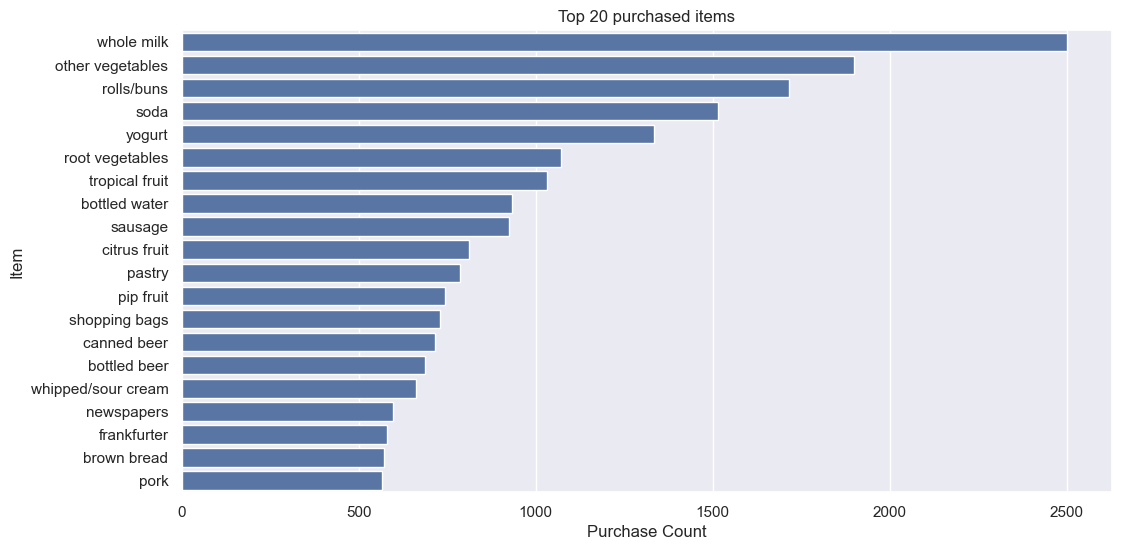

In [21]:
top_items = df['itemDescription'].value_counts().head(20)
plt.figure(figsize=(12,6))
sns.barplot(x=top_items.values, y=top_items.index)
plt.title("Top 20 purchased items")
plt.xlabel("Purchase Count")
plt.ylabel("Item")
plt.show()

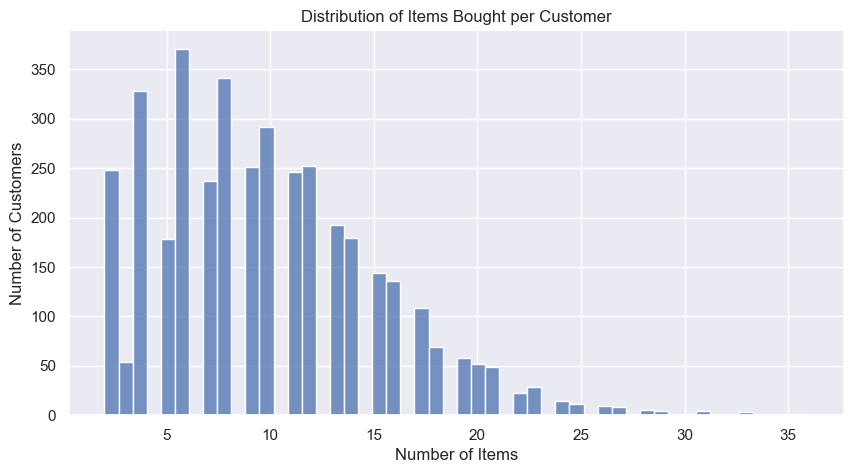

In [24]:
items_per_customer = df.groupby('Member_number')['itemDescription'].count()

plt.figure(figsize=(10,5))
sns.histplot(items_per_customer, bins=50)
plt.title("Distribution of Items Bought per Customer")
plt.xlabel("Number of Items")
plt.ylabel("Number of Customers")
plt.show()

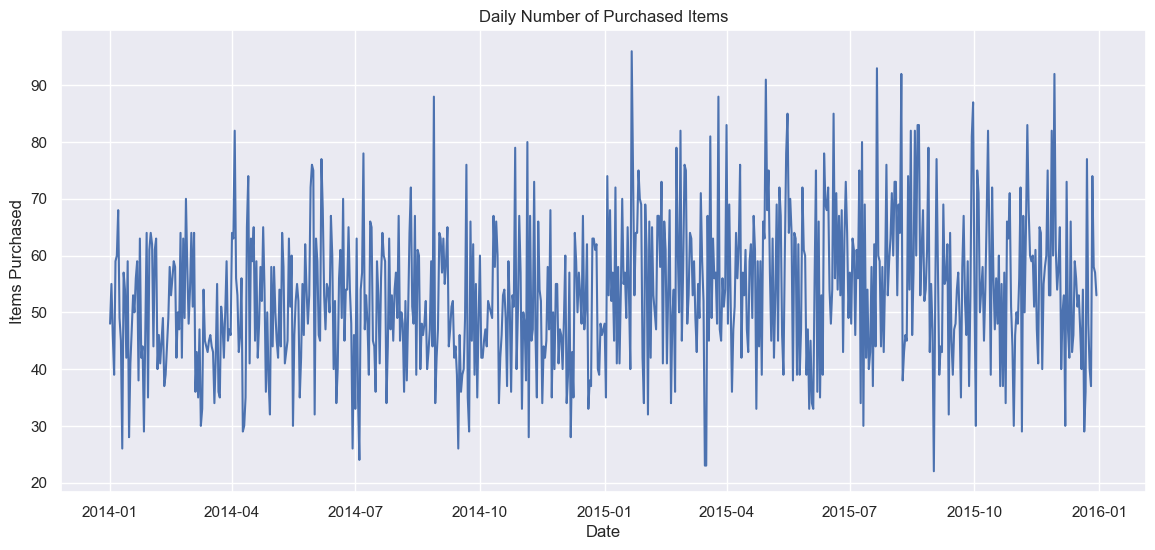

In [26]:
df['Date'] = pd.to_datetime(df['Date'])
daily = df.groupby(df['Date'].dt.date)['itemDescription'].count()

plt.figure(figsize=(14,6))
daily.plot()
plt.title("Daily Number of Purchased Items")
plt.xlabel("Date")
plt.ylabel("Items Purchased")
plt.show()
